# K-Nearest Neighbor Lab
Read over the sklearn info on [nearest neighbor learners](https://scikit-learn.org/stable/modules/neighbors.html#nearest-neighbors-classification)




In this lab you will use scikit-learn's k-nearest-neighbor implementations to classify the Glass and Magic Telescope datasets and to regress house prices, exploring the effects of normalization, distance weighting, and *k*. You will also design your own distance metric for mixed nominal-and-real data. Section percentages sum to 100%, with an optional 15% extra credit for coding KNN yourself.

In [2]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
import numpy as np
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 1 K-Nearest Neighbor (KNN) algorithm

### 1.1 (15%) Basic KNN Classification

Learn the [Glass data set](https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/glass_train.arff) using [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) with default parameters.
- Randomly split your data into train/test.  Anytime we don't tell you specifics (such as what percentage is train vs test) choose your own reasonable values
- Give typical train and test set accuracies after running with different random splits
- Print the output probabilities for a test set (predict_proba)
- Try it with different p values (Minkowskian exponent) and discuss any differences

In [ ]:
# Learn the glass data
! curl "https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/glass_train.arff" --output glass.arff
data_set = arff.loadarff('glass.arff')
df = pd.DataFrame(data_set[0])

df['Type_val'] = df['Type'].astype('category').cat.codes

X = df[["RI", "Na", "Mg", "Al", "Si", "'K'", "Ca", "Ba", "Fe"]]
y = df['Type_val']

for i in range(1, 102, 20):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

  knn = KNeighborsClassifier()
  knn.fit(X_train, y_train)

  train_accuracy = knn.score(X_train, y_train)
  test_accuracy = knn.score(X_test, y_test)

  print(f'Random State: {i}')
  print(f"Train Accuracy: {train_accuracy}")
  print(f"Test Accuracy: {test_accuracy}")

y_pred_proba = knn.predict_proba(X_test)
print("Output Probabilities:")
print(y_pred_proba)

for p in range(1, 5):
  knn = KNeighborsClassifier(p=p)
  knn.fit(X_train, y_train)

  train_accuracy = knn.score(X_train, y_train)
  test_accuracy = knn.score(X_test, y_test)

  print(f'P: {p}')
  print(f"Train Accuracy: {train_accuracy}")
  print(f"Test Accuracy: {test_accuracy}")
  y_pred_proba = knn.predict_proba(X_test)
  print("Output Probabilities:")
  print(y_pred_proba)

#### Discussion
What were your accuracies or output probabilities and how did different hyperparameter values affect the outcome? Discuss the differences you see.

when comparing p-values 2 to 4 the test accuracy was pretty consistently around 0.46 except for the first test which was about 0.53. the training accuracy was typically around 0.72. When the p-value was 1 the model was better at predicting

## 2 KNN Classification with normalization and distance weighting

Use the [magic telescope](https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/magic_telescope_train.arff) dataset

### 2.1 (5%) - Without Normalization or Distance Weighting
- Do random 80/20 train/test splits each time
- Run with k=3 and *without* distance weighting and *without* normalization
- Show train and test set accuracy

In [4]:
# Learn magic telescope data
! curl "https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/magic_telescope_train.arff" --output magic.arff
data_set = arff.loadarff('magic.arff')
df = pd.DataFrame(data_set[0])

df['class_val'] = df['class'].astype('category').cat.codes
X = df[["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist"]]
y = df['class_val']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors = 3, weights = 'uniform')
knn.fit(X_train, y_train)

train_accuracy = knn.score(X_train, y_train)
test_accuracy = knn.score(X_test, y_test)

print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  937k  100  937k    0     0  5256k      0 --:--:-- --:--:-- --:--:-- 5388k
Train Accuracy: 0.8765557017100071
Test Accuracy: 0.7887494941319304


#### Discussion
What did you observe in your results?

Both the test and training accuracy were very high. both above 0.75





### 2.2 (10%) With Normalization
- Try it with k=3 without distance weighting but *with* normalization of input features.  You may use any reasonable normalization approach (e.g. standard min-max normalization between 0-1, z-transform, etc.)

In [9]:
# Train/Predict with normalization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors = 3, weights = 'uniform')
knn.fit(X_train_scaled, y_train)

train_accuracy = knn.score(X_train_scaled, y_train)
test_accuracy = knn.score(X_test_scaled, y_test)

print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

Train Accuracy: 0.8971972073257108
Test Accuracy: 0.8150546337515177


#### Discussion
Discuss the results of using normalized data vs. unnormalized data

The test and training accuracy went up significantly between the normalized and unnormalized data

### 2.3 (10%) With Distance Weighting
- Try it with k=3 and with distance weighting *and* normalization

In [10]:
#Train/Predict with normalization and distance weighting
knn = KNeighborsClassifier(n_neighbors = 3, weights = 'distance')
knn.fit(X_train_scaled, y_train)

train_accuracy = knn.score(X_train_scaled, y_train)
test_accuracy = knn.score(X_test_scaled, y_test)

print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

Train Accuracy: 1.0
Test Accuracy: 0.8158640226628895


#### Discussion
Comparison and discuss the differences you see with distance weighting and normalization vs without.

the train accuracy was perfect and the test accuracy was better than without distance and normalization but the sam as without distance and with normalization

### 2.4 (10%) Different k Values
- Using your normalized data with distance weighting, create one graph with classification accuracy on the test set on the y-axis and k values on the x-axis.
- Use values of k from 1 to 15.  Use the same train/test split for each.

Text(0, 0.5, 'Accuracy')

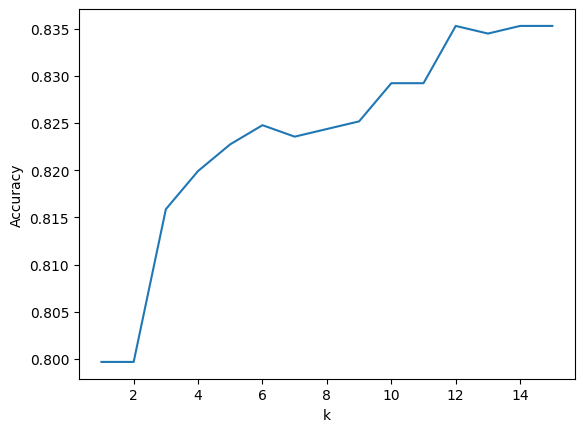

In [11]:
# Calculate and Graph classification accuracy vs k values
accuracies = []
for k in range(1,16):
  knn = KNeighborsClassifier(n_neighbors = k, weights = 'distance')
  knn.fit(X_train_scaled, y_train)

  test_accuracy = knn.score(X_test_scaled, y_test)

  accuracies.append(test_accuracy)

plt.plot(range(1,16), accuracies)
plt.xlabel('k')
plt.ylabel('Accuracy')

#### Discussion
How do the k values affect your results?

As the value of k increases, accuracy increases

## 3 KNN Regression with normalization and distance weighting

Use the [sklean KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor) on the [housing price prediction](https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/housing_train.arff) problem.  
### 3.1 (5%) Ethical Data
This is the classic Boston Housing dataset. It contains a feature that encodes a racial proxy of each neighborhood, and using it as a predictor bakes that bias into any model trained on it. scikit-learn deprecated `load_boston` in version 1.2 for exactly this reason (see the [sklearn note](https://scikit-learn.org/1.0/modules/generated/sklearn.datasets.load_boston.html)). Look at the feature list, identify the inappropriate feature, and discuss in one paragraph *which* feature it is, *why* it is a problem, and *what* you would do about it if you were shipping this model.


#### Discussion
Discuss the inappropriate feature. Which one and why?

Variable B was the inappropriate feature, because it assumed housing was positively impacted by racial segregation and there was not enough data to back up the claim

### 3.2 (15%) - KNN Regression
- Do random 80/20 train/test splits each time
- Run with k=3
- Print the score (coefficient of determination) and Mean Absolute Error (MAE) for the train and test set for the cases of
  - No input normalization and no distance weighting
  - Normalization and no distance weighting
  - Normalization and distance weighting
- Normalize inputs features where needed but do not normalize the output

In [25]:
# Learn and experiment with housing price prediction data
! curl 'https://raw.githubusercontent.com/BYU-CS-472/CS472/master/datasets/housing_train.arff' --output housing.arff
data_set = arff.loadarff('housing.arff')
df = pd.DataFrame(data_set[0])
df.head()

X = df[["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsRegressor(n_neighbors = 3, weights = 'uniform')
knn.fit(X_train, y_train)

coefficient_of_determination = knn.score(X_train, y_train)
mae = np.mean(np.abs(y_train - knn.predict(X_train)))
coefficient_of_determination_t = knn.score(X_test, y_test)
mae_t = np.mean(np.abs(y_test - knn.predict(X_test)))

print("No normalization and no distance weighting")
print(f"Train Coefficient of Determination: {coefficient_of_determination}")
print(f"Train Mean Absolute Error: {mae}")
print(f"Test Coefficient of Determination: {coefficient_of_determination_t}")
print(f"Test Mean Absolute Error: {mae_t}")

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn.fit(X_train_scaled, y_train)

coefficient_of_determination = knn.score(X_train_scaled, y_train)
mae = np.mean(np.abs(y_train - knn.predict(X_train_scaled)))
coefficient_of_determination_t = knn.score(X_test_scaled, y_test)
mae_t = np.mean(np.abs(y_test - knn.predict(X_test_scaled)))

print("normalization and no distance weighting")
print(f"Coefficient of Determination: {coefficient_of_determination}")
print(f"Mean Absolute Error: {mae}")
print(f"Test Coefficient of Determination: {coefficient_of_determination_t}")
print(f"Test Mean Absolute Error: {mae_t}")


knn = KNeighborsRegressor(n_neighbors = 3, weights = 'distance')
knn.fit(X_train_scaled, y_train)

coefficient_of_determination = knn.score(X_train_scaled, y_train)
mae = np.mean(np.abs(y_train - knn.predict(X_train_scaled)))
coefficient_of_determination_t = knn.score(X_test_scaled, y_test)
mae_t = np.mean(np.abs(y_test - knn.predict(X_test_scaled)))

print("normalization and distance weighting")
print(f"Coefficient of Determination: {coefficient_of_determination}")
print(f"Mean Absolute Error: {mae}")
print(f"Test Coefficient of Determination: {coefficient_of_determination_t}")
print(f"Test Mean Absolute Error: {mae_t}")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 34205  100 34205    0     0   124k      0 --:--:-- --:--:-- --:--:--  124k
No normalization and no distance weighting
Train Coefficient of Determination: 0.78694667619542
Train Mean Absolute Error: 3.1416666666666666
Test Coefficient of Determination: 0.448529655225832
Test Mean Absolute Error: 3.297069597069597
normalization and no distance weighting
Coefficient of Determination: 0.904051745258055
Mean Absolute Error: 2.0167582417582417
Test Coefficient of Determination: 0.8058610883199355
Test Mean Absolute Error: 2.013186813186813
normalization and distance weighting
Coefficient of Determination: 1.0
Mean Absolute Error: 0.0
Test Coefficient of Determination: 0.8057187838113368
Test Mean Absolute Error: 2.0214988766697233


#### Discussion
Discuss your results. How did the hyperparameters affect your results? Discuss each one and combinations of each.

no normalization had the weakest results; it had the lowest coefficients and highest MAEs. Normalization and no distance weighting increased the coefficient signnificantly ond slightly lowered the MAE. Normalization and distance weighting increased the train data coefficient to 1 and the MAE to 0 but the test data remains the same as the previous's test. Normalizing data appears to increase the coefficent of determination and distance weighting brings the train data to a coefficiant of 1 and MAE to 0.

### 3.3 (10%)  Different k Values
- Using housing with normalized data and distance weighting, create one graph with MAE on the test set on the y-axis and k values on the x-axis
- Use values of k from 1 to 15.  Use the same train/test split for each.

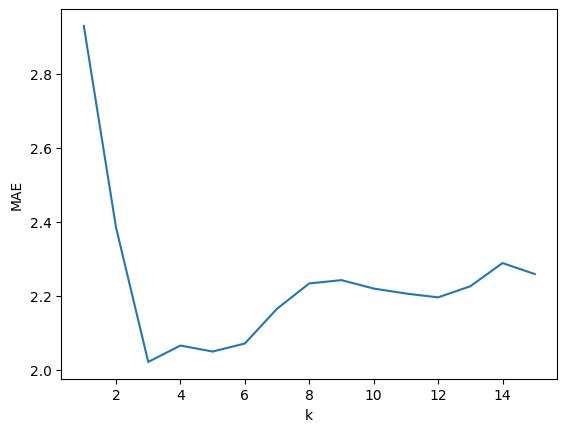

In [26]:
# Learn and graph for different k values
mae_values = []
for k in range(1,16):
  knn = KNeighborsRegressor(n_neighbors = k, weights = 'distance')
  knn.fit(X_train_scaled, y_train)
  mae = np.mean(np.abs(y_test - knn.predict(X_test_scaled)))
  mae_values.append(mae)

plt.plot(range(1,16), mae_values)
plt.xlabel('k')
plt.ylabel('MAE')
plt.show()

#### Discussion
How did the k values affect your results for this dataset? How does that compare to your previous work in this lab?

The MAE steeply decreases as the k value increases the first 3, but after that the MAE increases slowly as k increases

## 4. (20%) KNN with nominal and real data

- Use the [Lymphography dataset](https://archive.ics.uci.edu/dataset/63/lymphography) from UCI. You can install `ucimlrepo` (`!pip install ucimlrepo`) and load it with `from ucimlrepo import fetch_ucirepo; ds = fetch_ucirepo(id=63)`, or download the ARFF from UCI directly.
- Use a 80/20 split of the data for the training/test set
- This dataset has both continuous and nominal attributes
- Implement a distance metric which uses Euclidean distance for continuous features and 0/1 distance for nominal. Hints:
    - Change the nominal features in the data set to integer values since KNeighborsClassifier expects numeric features. I used `LabelEncoder` on the nominal features.
    - Keep a list of which features are nominal so your metric can decide which distance to use.
    - Your metric is a plain function of two 1-D feature vectors:
        ```python
        def mixed_metric(x, y):
            d = 0.0
            for i, is_nominal in enumerate(NOMINAL_MASK):
                if is_nominal:
                    d += 0 if x[i] == y[i] else 1
                else:
                    d += (x[i] - y[i]) ** 2
            return d ** 0.5

        clf = KNeighborsClassifier(metric=mixed_metric)
        ```
- Use your own choice for k and other parameters


In [42]:
# Train/Predict lymph with your own distance metric
from ucimlrepo import fetch_ucirepo; ds = fetch_ucirepo(id=63)
from sklearn.impute import SimpleImputer

X = ds.data.features
y = ds.data.targets.iloc[:, 0]



nominal_columns = X.select_dtypes(include=['object', 'category']).columns

for col in nominal_columns:
    X[col] = X[col].astype(str)
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X = X.dropna(axis=1, how='all')

NOMINAL_MASK = [True] * X.shape[1]

print("Number of features:", X.shape[1])
print("Number in mask:", len(NOMINAL_MASK))
print("Columns:", X.columns.tolist())
print("Nominal:", nominal_columns.tolist())

imputer = SimpleImputer(strategy='most_frequent')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def mixed_metric(x, y):
    d = 0.0
    for i, is_nominal in enumerate(NOMINAL_MASK):
        if is_nominal:
            d += 0 if x[i] == y[i] else 1
        else:
            d += (x[i] - y[i]) ** 2
    return d ** 0.5

knn = KNeighborsClassifier(metric=mixed_metric)
knn.fit(X_train, y_train)

train_accuracy = knn.score(X_train, y_train)
test_accuracy = knn.score(X_test, y_test)

print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

Number of features: 18
Number in mask: 18
Columns: ['lymphatics', 'block of affere', 'bl. of lymph. c', 'bl. of lymph. s', 'by pass', 'extravasates', 'regeneration of', 'early uptake in', 'lym.nodes dimin', 'lym.nodes enlar', 'changes in lym', 'defect in node', 'changes in node', 'changes in node', 'changes in stru', 'special forms', 'dislocation of', 'exclusion of no']
Nominal: []
Train Accuracy: 0.8728813559322034
Test Accuracy: 0.8


#### Discussion
Explain your distance metric and discuss your results

we used euclidian distance. the tes accuracy was about 0.8 and the train accuracy was 0.87

## 5. (Optional 15% extra credit) Code up your own KNN Learner
Below is a scaffold you could use if you want. Requirements for this task:
- Your model should support the methods shown in the example scaffold below
- Use Euclidean distance to decide closest neighbors
- Implement both the classification and regression versions
- Include optional distance weighting for both algorithms
- Run your algorithm on the magic telescope and housing data sets above and discuss and compare your results

*Discussion*

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class KNNClassifier(BaseEstimator,ClassifierMixin):
    def __init__(self, columntype=[], weight_type='inverse_distance'): ## add parameters here
        """
        Args:
            columntype for each column tells you if continues[real] or if nominal[categoritcal].
            weight_type: inverse_distance voting or if non distance weighting. Options = ["no_weight","inverse_distance"]
        """
        self.columntype = columntype #Note This won't be needed until part 5
        self.weight_type = weight_type

    def fit(self, data, labels):
        """ Fit the data; run the algorithm (for this lab really just saves the data :D)
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
            y (array-like): A 2D numpy array with the training targets
        Returns:
            self: this allows this to be chained, e.g. model.fit(X,y).predict(X_test)
        """
        return self

    def predict(self, data):
        """ Predict all classes for a dataset X
        Args:
            X (array-like): A 2D numpy array with the training data, excluding targets
        Returns:
            array, shape (n_samples,)
                Predicted target values per element in X.
        """
        pass

    #Returns the Mean score given input data and labels
    def score(self, X, y):
        """ Return accuracy of model on a given dataset. Must implement own score function.
        Args:
            X (array-like): A 2D numpy array with data, excluding targets
            y (array-like): A 2D numpy array with targets
        Returns:
            score : float
                Mean accuracy of self.predict(X) wrt. y.
        """
        return 0